In [4]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
#from torchmetrics.regression import R2Score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
from val import calculate_metrics
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

/home/marcos/.pyenv/versions/3.10.13/envs/gnn-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
#from chronos import ChronosPipeline
from chronos import BaseChronosPipeline
from chronos import ChronosPipeline, ChronosBoltPipeline

In [3]:
#print(ChronosBoltPipeline.predict.__doc__)  # for Chronos-Bolt models

In [4]:
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
#plt.style.use('seaborn-whitegrid')
#pd.set_option('display.float_format', '{:.16f}'.format)
warnings.filterwarnings('ignore')

## Data

In [5]:
def load_datasets(filepath):
    """Carrega os datasets de arquivos pickle."""
    try:
        with open(filepath, 'rb') as f:
            dataset = pickle.load(f)
        return dataset
    except IOError as e:
        log.error(f"Erro ao carregar o dataset: {e}")
    except pickle.PickleError as e:
        log.error(f"Erro ao desserializar o dataset: {e}")
        traceback.print_exception(e)

In [6]:
fpath_root = "/mnt/data/marcos/data/node_regression_bus/data_split/"

In [7]:
os.listdir(fpath_root)

['test.pkl',
 'train.pkl',
 'val.pkl',
 'loader_03-04_2024.parquet',
 'modify',
 'loader_03-04_2024.csv']

In [8]:
test_dataset = load_datasets(f'{fpath_root}test.pkl')
# x (dados de input)
test_dataset[0].x.shape

torch.Size([2871, 280])

In [9]:
# x (dados de input)
test_dataset[0].y.shape

torch.Size([2871, 200])

In [10]:
inference_size = test_dataset[0].y.shape[1]
inference_size

200

In [11]:
nodes = [53,  365,  382,  666,  701, 1326, 1404, 1569, 1916, 2617]

In [12]:
stops = {53: '125960550',
         365: '230565994',
         382: '258781031',
         666: '43768720',
         701: '44072192',
         1326: '44783654',
         1404: '44783914',
         1569: '44784438',
         1916: '45833547',
         2617: '47568123'}

## Alterar a partir daqui

## Model

In [6]:
model_name = "chronos-t5-small"
pipeline = BaseChronosPipeline.from_pretrained(
    f"amazon/{model_name}",  # use "amazon/chronos-bolt-small" for the corresponding Chronos-Bolt model
    device_map="cuda",  # use "cpu" for CPU inference
    torch_dtype=torch.bfloat16,
)

In [ ]:
# both
# model_name = "chronos-bolt-base"
# pipeline = ChronosBoltPipeline.from_pretrained(
#     f"amazon/{model_name}",
#     device_map="cuda",  # use "cpu" for CPU inference and "mps" for Apple Silicon
#     torch_dtype=torch.bfloat16,
# )

### Inference

In [62]:
scores_error = {'node': [], 'batch': [], 'mae': [], 'mse': [], 'r2': [], 'mape': []}
targets = {}
cost, time = 0, 0
dfs = []

inference = {"node": [],  "quantiles": [], "mean": []}

for node in nodes[:1]:
    dfs_pred = []   
    targets[node] = []
    for time, snapshot in tqdm(enumerate(test_dataset)):
        snapshot.to('cpu')

        #
        # (alterar aqui o modelo)
        #
        forecast = pipeline.predict(context=torch.tensor(snapshot.x[node,:]),
                                    prediction_length=inference_size,
                                    limit_prediction_length=False,
                                    num_samples=1)
        #
        y_hat = forecast.view(-1)
        #
        
        quantiles, mean = pipeline.predict_quantiles(
            context=torch.tensor(snapshot.x[node,:]),
            prediction_length=inference_size,
            quantile_levels=[0.1, 0.5, 0.9],
        )
        
        # nao alterar mais abaixo
    
        cost = cost + torch.mean((y_hat-snapshot.y)**2)
        y_true = snapshot.y.cpu().data.numpy()
        y_pred = y_hat.cpu().data.numpy()
        
        scores_error['node'].append(stops[node])
        scores_error['batch'].append(time)
        scores_error['mse'].append(mean_squared_error(y_true[node,:], y_pred))
        scores_error['mae'].append(mean_absolute_error(y_true[node,:], y_pred))
        scores_error['r2'].append(r2_score(y_true[node,:], y_pred))
        scores_error['mape'].append(mean_absolute_percentage_error(y_true[node,:], y_pred))
        
        targets[node].append({"input": snapshot.x[node,:].cpu().numpy(), 
                              'true': snapshot.y[node,:].cpu().data.numpy(),
                              'pred': y_pred,
                              'node': stops[node], 
                              'quantiles': quantiles,
                              'mean': mean,
                             })
        
    cost = cost / (time+1)
    cost = cost.item()
    log.info(f"node: {node} MSE test: {cost:.4f}")

0it [00:00, ?it/s]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
1it [00:04,  4.28s/it]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
2it [00:08,  4.03s/it]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
3it [00:12,  4.01s/it]We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is n

In [8]:
targets.keys()

NameError: name 'targets' is not defined

In [9]:
with open(f'results/{model_name}-targets.pkl', 'wb') as f:
    pickle.dump(targets, f)

NameError: name 'targets' is not defined

In [1]:
batch_idx = 0
node_ts = targets[53]
forecast_index = range(len(node_ts[batch_idx]["input"]), 
                       len(node_ts[batch_idx]["input"]) + node_ts[batch_idx]["true"].shape[0])

plt.figure(figsize=(15,5))
plt.plot(node_ts[batch_idx]["input"], '--', label="time series input")
plt.plot(forecast_index, node_ts[batch_idx]["true"], '--', label="time series ground truth")
plt.plot(forecast_index, node_ts[batch_idx]["pred"], '--', label="forecasting")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

NameError: name 'targets' is not defined

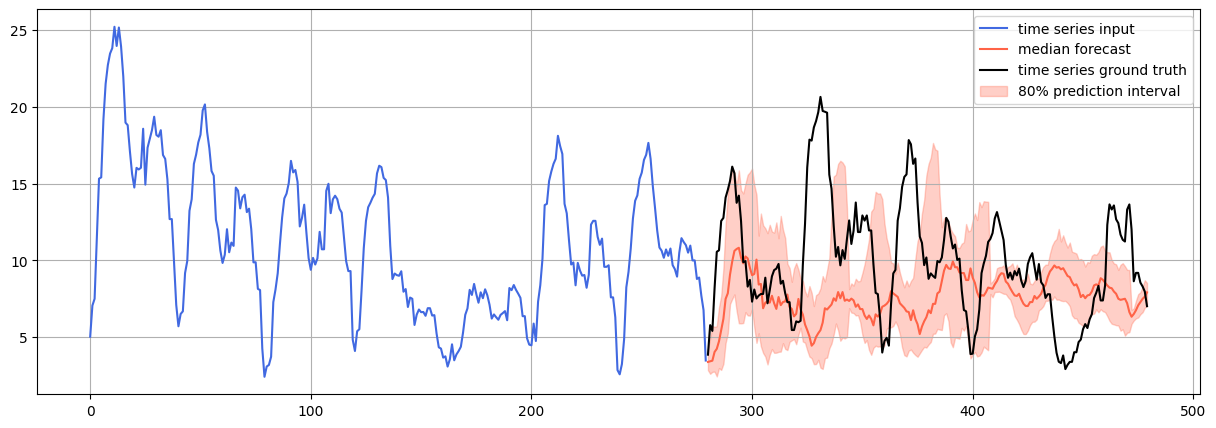

In [75]:
quantiles = node_ts[batch_idx]["quantiles"]
low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

plt.figure(figsize=(15,5))
plt.plot(node_ts[batch_idx]["input"], color="royalblue", label="time series input")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.plot(forecast_index, node_ts[batch_idx]["true"], color="k", label="time series ground truth")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()

In [68]:
df_results = pd.DataFrame(scores_error)
df_results

,node,batch,mae,mse,r2,mape
0,125960550,0,4.751236,36.435028,-1.513076,0.466158
1,125960550,1,3.825767,21.288189,-0.564401,0.387753
2,125960550,2,3.145729,15.849104,-0.112518,0.355886
3,125960550,3,4.818396,36.318985,-1.402165,0.474547
4,125960550,4,3.977620,24.267214,-0.842425,0.538362
5,125960550,5,3.653154,22.714888,-0.665219,0.422475
6,125960550,6,4.118580,25.414902,-0.702668,0.438186
7,125960550,7,4.917761,36.882904,-1.699100,0.477389
8,125960550,8,4.012192,24.729990,-0.731373,0.410747
9,125960550,9,4.310881,28.309492,-1.025622,0.542196


In [69]:
df_results["model"] = model_name
df_results.to_parquet(f"cronos-{model_name}-batch.parquet", index=False)

In [70]:
df_results

,node,batch,mae,mse,r2,mape,model
0,125960550,0,4.751236,36.435028,-1.513076,0.466158,chronos-t5-small
1,125960550,1,3.825767,21.288189,-0.564401,0.387753,chronos-t5-small
2,125960550,2,3.145729,15.849104,-0.112518,0.355886,chronos-t5-small
3,125960550,3,4.818396,36.318985,-1.402165,0.474547,chronos-t5-small
4,125960550,4,3.977620,24.267214,-0.842425,0.538362,chronos-t5-small
5,125960550,5,3.653154,22.714888,-0.665219,0.422475,chronos-t5-small
6,125960550,6,4.118580,25.414902,-0.702668,0.438186,chronos-t5-small
7,125960550,7,4.917761,36.882904,-1.699100,0.477389,chronos-t5-small
8,125960550,8,4.012192,24.729990,-0.731373,0.410747,chronos-t5-small
9,125960550,9,4.310881,28.309492,-1.025622,0.542196,chronos-t5-small


In [71]:
df_results.pivot_table(index=["model", "node"], 
                       values=["mae", "mse", "r2", "mape"], 
                       aggfunc="mean").reset_index()

,model,node,mae,mape,mse,r2
0,chronos-t5-small,125960550,5.368558,0.565038,47.906198,-0.957377


In [72]:
df_results.pivot_table(index=["model"], 
                       values=["mae", "mse", "r2", "mape"], 
                       aggfunc="mean").reset_index()

,model,mae,mape,mse,r2
0,chronos-t5-small,5.368558,0.565038,47.906198,-0.957377
